<hr style="border:2px solid #0281c9"> </hr>

<img align="left" alt="ESO Logo" src="http://archive.eso.org/i/esologo.png">  

<div align="center">
  <h1 style="color: #0281c9; font-weight: bold;">ESO Science Archive</h1> 
  <h2 style="color: #0281c9; font-weight: bold;">Jupyter Notebooks</h2>
</div>

<hr style="border:2px solid #0281c9"> </hr>

# **Query Paranal Meteorological Conditions with TAP**

This notebook shows how to retrieve basic weather telemetry from the Paranal Astronomical Site Monitor (ASM) table, `asm.meteo_paranal`, using the ESO TAP service through `astroquery.eso`.

The example follows a compact workflow:

- inspect the TAP table metadata so the column names, units, and descriptions are explicit
- query one Paranal night at one-minute cadence
- select a small set of commonly useful quantities: pressure, relative humidity, temperature, dew point, wind speed, wind direction, and rain intensity
- make a quick-look time-series plot that groups related measurements on shared axes

The measurements are ambient-condition telemetry from sensors around the VLT platform. Several columns encode the sensor height in their names, for example `temp_2m` for temperature 2 m above the platform and `wind_speed_30m` for wind speed 30 m above the platform. The notebook is meant as a template: change the time interval or selected columns to adapt it to a science observation, calibration check, or observing-condition summary.

<hr style="border:2px solid #0281c9"> </hr>


## **Importing the necessary modules**

We use `Eso.query_tap()` for the archive queries, `astropy.time.Time` to parse the ISO timestamps returned by TAP, and `matplotlib` for the quick-look plot.


In [1]:
import astroquery
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
from astroquery.eso import Eso

print(f"astroquery version: {astroquery.__version__}")

eso = Eso()

astroquery version: 0.4.12.dev505+gf2a77a615.d20260427


## **Inspect the table columns**


The Paranal meteorological table contains many related columns. The science columns usually store the one-minute mean value, while suffixes such as `_inst`, `_min`, `_max`, and `_dev` store instantaneous values or summary statistics over the same interval.

Before writing the science query, it is useful to query `TAP_SCHEMA.columns`. This metadata table tells us the exact column names, units, and archive descriptions for `asm.meteo_paranal`.


In [2]:
metadata_query = """
                SELECT column_name, unit, description
                FROM TAP_SCHEMA.columns
                WHERE table_name = 'asm.meteo_paranal'
                ORDER BY column_name
                """

meteo_columns = eso.query_tap(metadata_query)
meteo_columns

column_name,unit,description
object,object,object
integration,s,Timebin [s] used for measurement of ambient data sample.
midpoint_date,,Midpoint (time) of the measurement.
presqnh,hPa,Air Pressure Normalised: 1 minute average pressure normalised to sea level [hPa]. (sci. param.)
presqnh_dev,hPa,Air Pressure Normalised RMS: 1 minute RMS pressure normalized to sea level [hPa]. (eng. param.)
presqnh_inst,hPa,Air Pressure Normalised instantaneous: Pressure normalized to sea level at the end of the averaging period [hPa]. (eng. param.)
presqnh_max,hPa,Air Pressure Normalised max: 1 minute maximum pressure normalized to sea level [hPa]. (eng. param.)
presqnh_min,hPa,Air Pressure Normalised min: 1 minute minimum pressure normalized to sea level [hPa]. (eng. param.)
press_0m,hPa,Air Pressure: Temporal (1 minute) mean of observatory site ambient baromeric air pressure measured at 0m above the VLT platform during measurement period [hPa]. (sci. param.)
press_0m_dev,hPa,Air Pressure RMS: 1 minute RMS surface pressure variation at 0m above the VLT platform [hPa]. (eng. param.)


In [3]:
key_column_names = [
    "integration",
    "start_date",
    "midpoint_date",
    "press_0m",
    "presqnh",
    "rhum_2m",
    "rhum_30m",
    "temp_2m",
    "temp_30m",
    "tempdew_2m",
    "wind_speed_10m",
    "wind_speed_30m",
    "wind_dir_10m",
    "wind_dir_30m",
    "rain_m20m",
]

key_columns = meteo_columns[np.isin(meteo_columns["column_name"], key_column_names)]
key_columns["column_name", "unit", "description"]

column_name,unit,description
object,object,object
integration,s,Timebin [s] used for measurement of ambient data sample.
midpoint_date,,Midpoint (time) of the measurement.
presqnh,hPa,Air Pressure Normalised: 1 minute average pressure normalised to sea level [hPa]. (sci. param.)
press_0m,hPa,Air Pressure: Temporal (1 minute) mean of observatory site ambient baromeric air pressure measured at 0m above the VLT platform during measurement period [hPa]. (sci. param.)
rain_m20m,%,Rain intensity: 1 minute average rain percentage measured 20m below the VLT platform [%]. (sci. param.)
rhum_2m,%,Relative Humidity: Temporal (1 minute) mean of observatory site ambient relative humidity measured at sensor position 2m above the VLT platform during measurement period [%]. (sci. param.)
rhum_30m,%,Relative Humidity: Temporal (1 minute) mean of observatory site ambient relative humidity measured at sensor position 30m above the VLT platform during measurement period [%]. (sci. param.)
start_date,,The start time of the measurement.
temp_2m,Celsius,Ambient Temperature: Temporal (1 minute) mean of site ambient temperature measured at 2m above the VLT platform [degC]. (sci. param.)


## **Query the `asm.meteo_paranal` table**

The query below retrieves one Paranal night, from the evening of 2025-05-01 to the following morning. The time filter uses `start_date`, while the plot uses `midpoint_date`, the midpoint of each one-minute measurement interval.

Only the columns used later in the notebook are requested. This keeps the returned table compact and makes the plot configuration below easier to follow. To explore other weather quantities, add their names to `selected_columns` after checking the metadata table above.


In [4]:
start_time = "2025-05-01T21:00:00"
end_time = "2025-05-02T10:00:00"

selected_columns = [
    "start_date",
    "midpoint_date",
    "integration",
    "press_0m",
    "presqnh",
    "rhum_2m",
    "rhum_30m",
    "temp_2m",
    "temp_30m",
    "tempdew_2m",
    "wind_speed_10m",
    "wind_speed_30m",
    "wind_dir_10m",
    "wind_dir_30m",
    "rain_m20m",
]

column_list = ",\n    ".join(selected_columns)
meteo_query = f"""
                SELECT
                    {column_list}
                FROM asm.meteo_paranal
                WHERE start_date BETWEEN '{start_time}' AND '{end_time}'
                ORDER BY start_date
                """

meteo_table = eso.query_tap(meteo_query)
meteo_table[:5]

start_date,midpoint_date,integration,press_0m,presqnh,rhum_2m,rhum_30m,temp_2m,temp_30m,tempdew_2m,wind_speed_10m,wind_speed_30m,wind_dir_10m,wind_dir_30m,rain_m20m
,,s,hPa,hPa,%,%,Celsius,Celsius,Celsius,m.s**(-1),m.s**(-1),deg,deg,%
object,object,int16,float32,float32,int16,int16,float32,float32,float32,float32,float32,int16,int16,int16
2025-05-01T21:00:41Z,2025-05-01T21:01:11Z,60,745.08,1027.44,15,15,15.98,14.78,-10.56,8.78,8.43,343,346,1
2025-05-01T21:01:41Z,2025-05-01T21:02:11Z,60,745.07,1027.42,16,16,15.95,14.76,-10.16,8.45,7.88,343,341,1
2025-05-01T21:02:41Z,2025-05-01T21:03:11Z,60,745.08,1027.44,15,15,15.9,14.72,-10.79,8.3,8.57,348,358,1
2025-05-01T21:03:43Z,2025-05-01T21:04:13Z,60,745.03,1027.38,15,16,15.76,14.76,-10.59,7.93,7.63,331,344,1
2025-05-01T21:04:43Z,2025-05-01T21:05:13Z,60,745.03,1027.38,16,17,15.74,14.74,-9.9,8.05,8.07,336,341,1


## **Plot the weather time series**

The plot groups related quantities into separate panels with a shared time axis. This avoids mixing variables with different units while still making it easy to compare trends across the same night. Wind direction is shown with points rather than connected lines because the values wrap at 0/360 degrees.

The helper functions below handle two practical details: converting masked table values to `NaN` for plotting and downsampling automatically if a much longer time interval is queried.


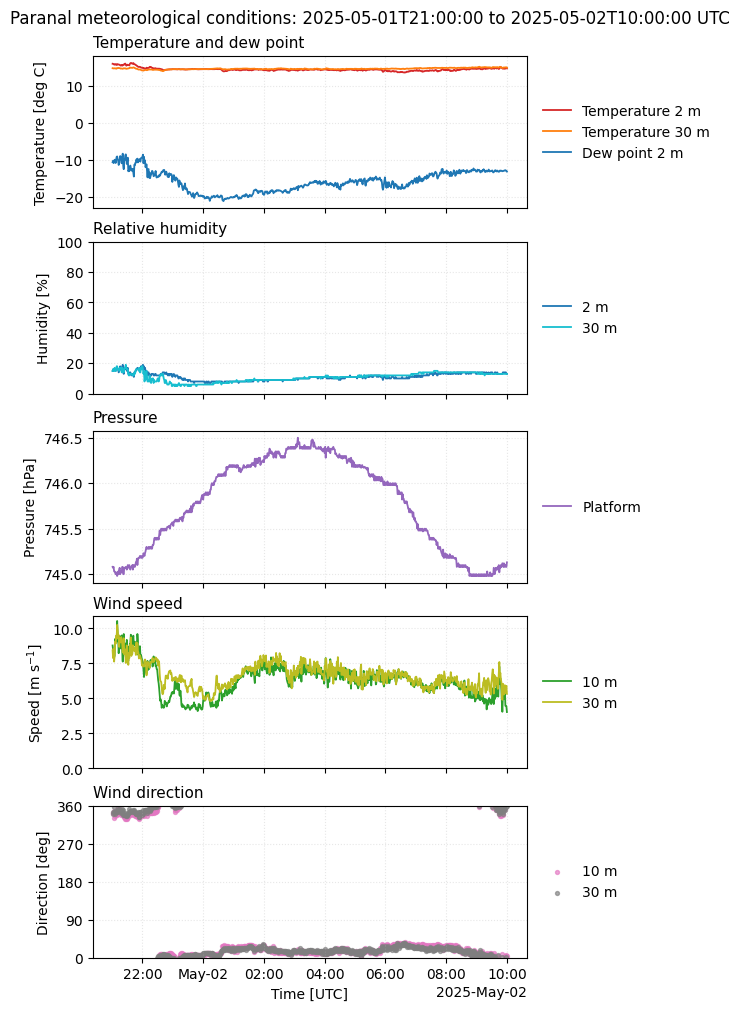

In [6]:
if len(meteo_table) == 0:
    raise ValueError("No rows returned. Choose a different time interval.")

max_points = 5000
sample = slice(None)
if len(meteo_table) > max_points:
    sample = np.linspace(0, len(meteo_table) - 1, max_points).astype(int)

time_values = np.asarray(meteo_table["midpoint_date"], dtype=str)
plot_time = Time(time_values, scale="utc").datetime[sample]


def column_values(column_name):
    values = np.asarray(meteo_table[column_name])
    if np.ma.isMaskedArray(values):
        values = np.ma.filled(values, np.nan)
    return np.asarray(values, dtype=float)[sample]


plot_groups = [
    {
        "title": "Temperature and dew point",
        "ylabel": "Temperature [deg C]",
        "series": [
            ("temp_2m", "Temperature 2 m", "tab:red"),
            ("temp_30m", "Temperature 30 m", "tab:orange"),
            ("tempdew_2m", "Dew point 2 m", "tab:blue"),
        ],
    },
    {
        "title": "Relative humidity",
        "ylabel": "Humidity [%]",
        "ylim": (0, 100),
        "series": [
            ("rhum_2m", "2 m", "tab:blue"),
            ("rhum_30m", "30 m", "tab:cyan"),
        ],
    },
    {
        "title": "Pressure",
        "ylabel": "Pressure [hPa]",
        "series": [("press_0m", "Platform", "tab:purple")],
    },
    {
        "title": "Wind speed",
        "ylabel": "Speed [m s$^{-1}$]",
        "ylim": (0, None),
        "series": [
            ("wind_speed_10m", "10 m", "tab:green"),
            ("wind_speed_30m", "30 m", "tab:olive"),
        ],
    },
    {
        "title": "Wind direction",
        "ylabel": "Direction [deg]",
        "ylim": (0, 360),
        "kind": "scatter",
        "series": [
            ("wind_dir_10m", "10 m", "tab:pink"),
            ("wind_dir_30m", "30 m", "tab:gray"),
        ],
    },
]

if "rain_m20m" in meteo_table.colnames:
    rain_values = column_values("rain_m20m")
    has_rain_signal = np.isfinite(rain_values).any() and np.nanmax(rain_values) > 5
else:
    has_rain_signal = False

if has_rain_signal:
    plot_groups.append(
        {
            "title": "Rain intensity",
            "ylabel": "Rain [%]",
            "ylim": (0, 100),
            "series": [("rain_m20m", "-20 m", "tab:blue")],
        }
    )

fig, axes = plt.subplots(
    len(plot_groups),
    1,
    figsize=(7, 2 * len(plot_groups)),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for ax, group in zip(axes, plot_groups):
    for column_name, label, color in group["series"]:
        if column_name not in meteo_table.colnames:
            continue

        values = column_values(column_name)
        if group.get("kind") == "scatter":
            ax.scatter(plot_time, values, s=8, color=color, alpha=0.65, label=label)
        else:
            ax.plot(plot_time, values, lw=1.3, color=color, label=label)

    ax.set_title(group["title"], loc="left", fontsize=11)
    ax.set_ylabel(group["ylabel"])
    ax.grid(alpha=0.3, linestyle=":")
    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.01, 0.5))

    if "ylim" in group:
        ax.set_ylim(*group["ylim"])
    if group["title"] == "Wind direction":
        ax.set_yticks([0, 90, 180, 270, 360])

locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
formatter = mdates.ConciseDateFormatter(locator)
axes[-1].xaxis.set_major_locator(locator)
axes[-1].xaxis.set_major_formatter(formatter)
axes[-1].set_xlabel("Time [UTC]")

fig.suptitle(f"Paranal meteorological conditions: {start_time} to {end_time} UTC")
plt.show()


<hr style="border:2px solid #0281c9">